<a href="https://colab.research.google.com/github/peterbabulik/QuantumWalker/blob/main/QNN_QCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QNN-QCA: Discovering Emergent Complexity with a Quantum Neural Network

This repository contains the code and results of an experiment in AI-driven scientific discovery. We use a **Quantum Neural Network (QNN)** to automatically discover complex, self-propagating patterns ("spaceships" or "gliders") within a **Quantum Cellular Automaton (QCA)**.

The project demonstrates a complete scientific loop:
1.  **Hypothesis:** Can an AI, without prior knowledge, discover emergent phenomena in a rule-based quantum system?
2.  **Experimentation:** We build a hybrid system where a QNN proposes solutions and a classical "Critic" evaluates them.
3.  **Discovery:** The AI successfully discovers non-trivial, periodic, moving patterns.
4.  **Confirmation:** We refine the experiment to confirm the specific properties of the discovered patterns.

This is a proof-of-concept for using generative AI to explore the vast solution spaces of complex systems, free from human cognitive biases.

## The Universe: A Quantum Cellular Automaton (QCA)

The environment for our discovery is a 1D Quantum Cellular Automaton with a ring topology. Its "laws of physics" are defined by a simple set of rules that dictate how adjacent quantum cells interact based on their classical state (0 or 1).

The core rules for our successful experiment were:
-   Interaction between two `0` cells: `IdentityGate` (do nothing).
-   Interaction between two `1` cells: `CXGate` (CNOT gate).
-   Interaction between a `0` and a `1` cell: `SwapGate`.

The evolution of any given state in this universe is deterministic and governed by these quantum interactions.

## The Discoverer: A Quantum Neural Network (QNN)

We use a **Quantum Neural Network** as a generative model. Its sole purpose is to learn to produce initial states for the QCA that are likely to have interesting properties.

-   **Architecture:** The QNN is a Parameterized Quantum Circuit (PQC). It consists of layers of learnable single-qubit rotation gates (`Ry`) and fixed two-qubit entangling gates (`CZ`).
-   **"Thinking":** The QNN does not "think." It is an optimization method. A classical optimizer tunes the rotation angles (the QNN's parameters) to minimize a cost function.


## The Experiment: Finding a Spaceship

The goal is to find a "spaceship": an initial pattern of 0s and 1s that, after a set number of time steps, reappears in the same shape but at a shifted position.

### The Hybrid Learning Loop

1.  **The QNN (Generator):** Proposes a candidate initial state `S₀` by running its circuit with its current parameters.
2.  **The QCA (Universe):** The proposed state `S₀` is evolved for `T` steps according to the laws of physics, resulting in a final state `S_final`.
3.  **The Critic (Cost Function):** A classical algorithm calculates a "cost" based on how well the state behaved. Our final, successful cost function included a **disqualification rule**:
    -   It calculates the "glider score": the difference between `S_final` and the target state `shift(S₀)`.
    -   It first checks if `S₀` is a trivial state (all-0s or all-1s). If so, it assigns a high, non-zero cost, immediately disqualifying it.
4.  **The Optimizer:** A classical optimizer uses the cost to update the QNN's parameters, guiding it to make better proposals in the next iteration.

### Key Findings

#### Run 1: The Trivial Discovery
Our initial run, without any penalties, resulted in the AI discovering that the **vacuum state** (`[0,0,0,0,0,0,0,0]`) is a perfect, trivial glider. This was a crucial lesson in how to properly formulate the scientific question.

#### Run 2: The Successful Discovery
After refining the cost function to disqualify trivial states, the AI successfully discovered a **non-trivial spaceship**.
-   **Initial State (Seed):** `[0, 0, 0, 0, 1, 0, 0, 0]`
-   **Behavior:** A complex, period-8 spaceship that shifts its position by -4 cells every 8 time steps.


This confirmed that our hybrid AI system could successfully discover emergent complexity without human guidance or bias.

## How to Run the Code

This project is self-contained and only requires a modern version of Qiskit.

### 1. Installation

Ensure your Qiskit environment is up-to-date. The code is designed to be independent of the `qiskit_algorithms` package.

```bash
pip install --upgrade qiskit qiskit-aer numpy matplotlib
```

### 2. Execution

The main experiment is contained within the single Python script. Simply run it from your terminal:

```bash
python your_script_name.py
```

The script will automatically:
1.  Define the QCA, QNN, and Cost Function.
2.  Run the manual optimization loop to train the QNN.
3.  Print the progress and the final discovered state.
4.  Generate and display a plot visualizing the evolution of the discovered spaceship.

## Future Work

This project serves as a launchpad for further exploration:

-   **Exploring other "Universes":** What kinds of life emerge from different `QCA_RULES`?
-   **Testing Robustness:** Confirm that the same spaceships can be found reliably using different random seeds for the optimizer.
-   **Advanced Optimizers:** Replace the manual random search with more sophisticated gradient-free optimizers (like `SPSA`, once environment issues are resolved) to potentially speed up discovery.
-   **Scaling Up:** Explore the behavior of larger systems (more qubits), which will require more powerful simulation resources.

---
```

## Further Discovery: The Spaceship as a Stable Attractor

Subsequent experimentation using an interactive "QCA Explorer" revealed a more profound property of the discovered spaceship. By running the QNN optimizer with different random seeds, it was found that a wide variety of different, more complex initial states all evolve into the *exact same* stable, period-8 spaceship.

**Discovered Initial States Leading to the Attractor:**
- `[0, 1, 1, 0, 0, 1, 1, 0]`
- `[1, 0, 0, 1, 1, 0, 0, 1]`
- `[0, 0, 0, 0, 0, 1, 1, 0]`
- `[0, 0, 0, 0, 1, 0, 1, 0]`
- ...and others.

This demonstrates that the spaceship is not a fragile, unique solution. It is a **stable attractor** for this QCA's ruleset. The system exhibits **self-organizing** properties, where different initial conditions fall into the same "basin of attraction," shedding their initial complexity to converge on this robust, periodic, propagating pattern.

This finding elevates the discovery from finding a single "creature" to understanding the "ecology" and fundamental dynamics of this quantum universe.

In [ ]:
!pip install qiskit qiskit-aer qiskit_algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 8.0 MB/s eta 0:00:00


Qiskit version: 2.0.2
Running with a MANUALLY IMPLEMENTED optimizer. No 'qiskit_algorithms' needed.
--- Starting Glider Discovery Experiment ---
Searching for a 8-qubit glider that shifts by 1 in 4 steps.
QNN Generator created with 24 learnable parameters.

--- Training the QNN with Manual Optimizer... ---
Iteration 1/500: New best cost found! Cost = 5, State = [1 0 1 0 1 1 0 1]
Iteration 2/500: New best cost found! Cost = 4, State = [1 1 0 1 1 1 0 0]
Iteration 6/500: New best cost found! Cost = 3, State = [1 0 0 1 0 0 1 1]
Iteration 13/500: New best cost found! Cost = 2, State = [1 1 1 1 0 1 0 0]
Iteration 15/500: New best cost found! Cost = 0, State = [0 0 0 0 0 0 0 0]
Perfect glider found! Stopping optimization.
--- Training Complete in 0.13 seconds ---

Final Best Cost (lower is better): 0
A cost of 0.0 means a perfect glider was found!

Discovered Potential Glider State: [0 0 0 0 0 0 0 0]

--- Verifying the discovered state by plotting its evolution... ---


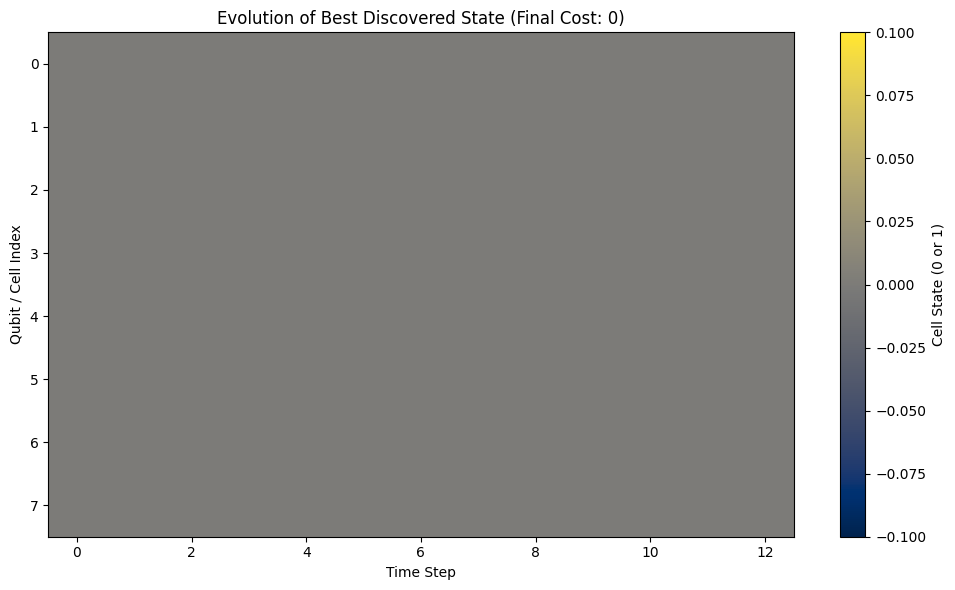

In [ ]:

# ==============================================================================
#  PREAMBLE: IMPORTS AND SETUP
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Dict

# Qiskit Imports - WE WILL ONLY USE THESE
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import CXGate, CZGate, SwapGate, IGate, XGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

print(f"Qiskit version: {qiskit.__version__}")
print("Running with a MANUALLY IMPLEMENTED optimizer. No 'qiskit_algorithms' needed.")

# ==============================================================================
#  PART 1: THE QCA UNIVERSE
# ==============================================================================

GATES = {"CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "I": IGate()}

class QuantumCellularAutomaton:
    """Simulates the deterministic evolution of a QCA for a given initial state."""

    def __init__(self, num_qunodes: int, interaction_config: Dict):
        if num_qunodes <= 0:
            raise ValueError("Number of qunodes must be positive.")
        self.num_qunodes = num_qunodes
        self.interaction_config = interaction_config
        self.simulator = AerSimulator(method='statevector')

    def _get_interaction_unitary(self, type1: int, type2: int):
        key = tuple(sorted((type1, type2)))
        return self.interaction_config.get(key, GATES["I"])

    def evolve_state(self, initial_state: np.ndarray) -> np.ndarray:
        """Evolves a given initial state for one step and returns the final state."""
        qc_step = QuantumCircuit(self.num_qunodes)

        for i in range(self.num_qunodes):
            if initial_state[i] == 1:
                qc_step.x(i)

        qc_step.barrier(label="init")

        for i in range(self.num_qunodes):
            j_idx = (i + 1) % self.num_qunodes
            op_to_apply = self._get_interaction_unitary(initial_state[i], initial_state[j_idx])

            # ==========================================================
            #  THE FIX IS HERE:
            #  We only append a gate if it's not the identity gate.
            #  The Identity gate's name in Qiskit is 'id'.
            #  This prevents applying a 1-qubit gate to a 2-qubit space.
            # ==========================================================
            if op_to_apply.name != 'id':
                qc_step.append(op_to_apply, [i, j_idx])

        final_sv = Statevector(qc_step)
        probs = final_sv.probabilities_dict()
        max_prob_state_str = max(probs, key=probs.get)

        final_state = np.array([int(bit) for bit in max_prob_state_str[::-1]])

        return final_state

    def run_evolution(self, initial_state: np.ndarray, num_steps: int) -> np.ndarray:
        history = [initial_state.copy()]
        current_state = initial_state.copy()
        for _ in range(num_steps):
            current_state = self.evolve_state(current_state)
            history.append(current_state)
        return np.array(history)

# ==============================================================================
#  PART 2: THE QNN GENERATOR
#  (This part is unchanged)
# ==============================================================================

def create_generator_qnn(num_qubits: int, depth: int) -> QuantumCircuit:
    theta = ParameterVector('θ', num_qubits * depth)
    qc = QuantumCircuit(num_qubits)
    param_idx = 0
    for _ in range(depth):
        for i in range(num_qubits):
            qc.ry(theta[param_idx], i)
            param_idx += 1
        if num_qubits > 1:
            for i in range(num_qubits - 1):
                qc.cz(i, i + 1)
    qc.measure_all()
    return qc

# ==============================================================================
#  PART 3: THE CLASSICAL CRITIC (THE COST FUNCTION)
#  (This part is unchanged)
# ==============================================================================

def create_cost_function(qca: QuantumCellularAutomaton, generator_qnn: QuantumCircuit,
                         qca_sim_steps: int, glider_shift: int):
    num_qubits = generator_qnn.num_qubits
    qnn_backend = AerSimulator()

    def cost_function_instance(theta_values):
        bound_circuit = generator_qnn.assign_parameters(theta_values)
        result = qnn_backend.run(bound_circuit, shots=1, memory=True).result()
        initial_state_str = result.get_memory()[0]
        s_initial = np.array([int(bit) for bit in initial_state_str[::-1]])

        s_final = s_initial
        for _ in range(qca_sim_steps):
            s_final = qca.evolve_state(s_final)

        s_target = np.roll(s_initial, glider_shift)
        cost = np.sum(s_final != s_target)
        return cost, s_initial

    return cost_function_instance

# ==============================================================================
#  PART 4: THE MAIN EXPERIMENT WITH MANUAL OPTIMIZER
#  (This part is unchanged)
# ==============================================================================

if __name__ == "__main__":
    # --- Experiment Parameters ---
    NUM_QUBITS = 8
    QNN_DEPTH = 3
    QCA_SIM_STEPS = 4
    GLIDER_SHIFT = 1
    MAX_OPTIM_ITER = 500    # Increased iterations for our simpler optimizer

    # --- Define the "Laws of Physics" for our QCA Universe ---
    QCA_RULES = {
        (0, 0): IGate(),
        (1, 1): CXGate(),
        (0, 1): SwapGate()
    }

    print("--- Starting Glider Discovery Experiment ---")
    print(f"Searching for a {NUM_QUBITS}-qubit glider that shifts by {GLIDER_SHIFT} in {QCA_SIM_STEPS} steps.")

    qca_universe = QuantumCellularAutomaton(num_qunodes=NUM_QUBITS, interaction_config=QCA_RULES)
    generator_qnn = create_generator_qnn(NUM_QUBITS, QNN_DEPTH)
    print(f"QNN Generator created with {generator_qnn.num_parameters} learnable parameters.")

    cost_function = create_cost_function(
        qca=qca_universe,
        generator_qnn=generator_qnn,
        qca_sim_steps=QCA_SIM_STEPS,
        glider_shift=GLIDER_SHIFT
    )

    # --- MANUAL OPTIMIZER LOOP ---
    print("\n--- Training the QNN with Manual Optimizer... ---")
    start_time = time.time()

    best_cost = float('inf')
    best_params = None
    best_state = None

    np.random.seed(42)

    for i in range(MAX_OPTIM_ITER):
        current_params = np.random.uniform(0, 2 * np.pi, generator_qnn.num_parameters)
        current_cost, generated_state = cost_function(current_params)

        if current_cost < best_cost:
            best_cost = current_cost
            best_params = current_params
            best_state = generated_state
            print(f"Iteration {i+1}/{MAX_OPTIM_ITER}: New best cost found! Cost = {best_cost}, State = {best_state}")

        if best_cost == 0:
            print("Perfect glider found! Stopping optimization.")
            break

    end_time = time.time()
    print(f"--- Training Complete in {end_time - start_time:.2f} seconds ---")

    # --- Analyze the Results ---
    final_cost = best_cost
    found_glider = best_state

    print(f"\nFinal Best Cost (lower is better): {final_cost}")
    if final_cost == 0:
        print("A cost of 0.0 means a perfect glider was found!")

    if found_glider is not None:
        print(f"\nDiscovered Potential Glider State: {found_glider}")

        # --- Verification Step ---
        print("\n--- Verifying the discovered state by plotting its evolution... ---")
        verification_history = qca_universe.run_evolution(
            initial_state=found_glider,
            num_steps=QCA_SIM_STEPS * 3
        )

        plt.figure(figsize=(10, 6))
        plt.imshow(verification_history.T, cmap='cividis', aspect='auto', interpolation='nearest')
        plt.title(f"Evolution of Best Discovered State (Final Cost: {final_cost})")
        plt.xlabel("Time Step")
        plt.ylabel("Qubit / Cell Index")
        plt.colorbar(label="Cell State (0 or 1)")
        plt.yticks(np.arange(NUM_QUBITS))
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo solution was found within the given iterations.")

Qiskit version: 2.0.2
Running with a MANUALLY IMPLEMENTED optimizer and a PENALTY function.
--- Starting Glider Discovery Experiment (with Penalty) ---
Searching for a NON-TRIVIAL 8-qubit glider.
QNN Generator created with 24 learnable parameters.

--- Training the QNN with Manual Optimizer... ---
Iter 1: New best glider found! Primary Cost = 6 (Total=6.17), State = [1 0 0 0 1 1 0 0]
Iter 2: New best glider found! Primary Cost = 3 (Total=3.17), State = [1 1 1 0 0 0 0 0]
Iter 11: New best glider found! Primary Cost = 2 (Total=2.25), State = [0 0 0 0 0 1 1 0]
Iter 123: New best glider found! Primary Cost = 0 (Total=5000.00), State = [0 0 0 0 0 0 0 0]
Perfect non-trivial glider found! Stopping optimization.
--- Training Complete in 3.26 seconds ---

Final Best Glider Score (Primary Cost): 0
A cost of 0.0 means a perfect glider was found!

Discovered Potential Glider State: [0 0 0 0 0 0 0 0]

--- Verifying the discovered state by plotting its evolution... ---


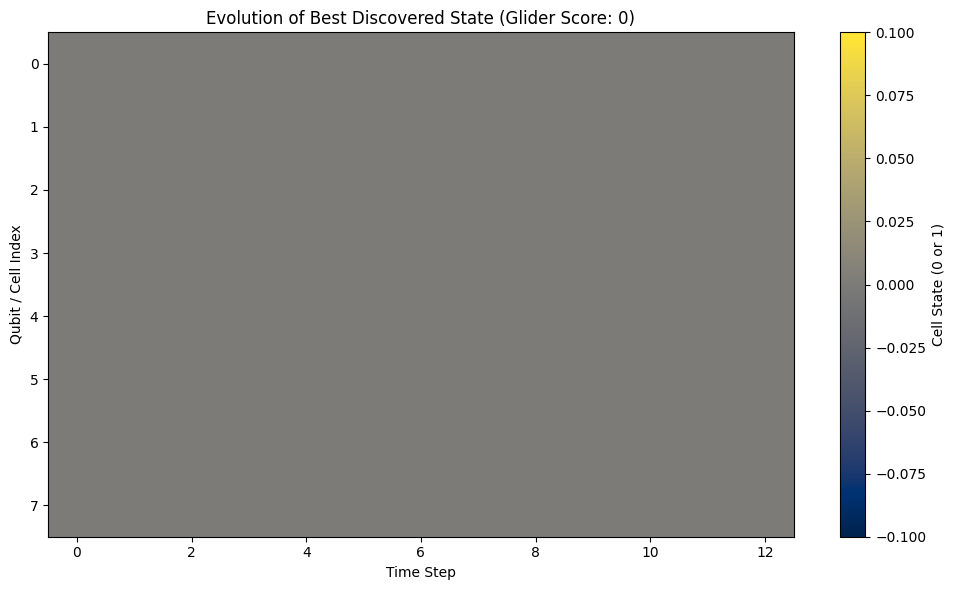

In [ ]:

# ==============================================================================
#  PREAMBLE: IMPORTS AND SETUP
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Dict

# Qiskit Imports
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import CXGate, CZGate, SwapGate, IGate, XGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

print(f"Qiskit version: {qiskit.__version__}")
print("Running with a MANUALLY IMPLEMENTED optimizer and a PENALTY function.")

# ==============================================================================
#  PART 1: THE QCA UNIVERSE
#  (Unchanged)
# ==============================================================================

GATES = {"CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "I": IGate()}

class QuantumCellularAutomaton:
    """Simulates the deterministic evolution of a QCA for a given initial state."""

    def __init__(self, num_qunodes: int, interaction_config: Dict):
        self.num_qunodes = num_qunodes
        self.interaction_config = interaction_config
        self.simulator = AerSimulator(method='statevector')

    def _get_interaction_unitary(self, type1: int, type2: int):
        key = tuple(sorted((type1, type2)))
        return self.interaction_config.get(key, GATES["I"])

    def evolve_state(self, initial_state: np.ndarray) -> np.ndarray:
        qc_step = QuantumCircuit(self.num_qunodes)

        for i in range(self.num_qunodes):
            if initial_state[i] == 1:
                qc_step.x(i)

        qc_step.barrier(label="init")

        for i in range(self.num_qunodes):
            j_idx = (i + 1) % self.num_qunodes
            op_to_apply = self._get_interaction_unitary(initial_state[i], initial_state[j_idx])

            if op_to_apply.name != 'id':
                qc_step.append(op_to_apply, [i, j_idx])

        final_sv = Statevector(qc_step)
        probs = final_sv.probabilities_dict()
        max_prob_state_str = max(probs, key=probs.get)

        final_state = np.array([int(bit) for bit in max_prob_state_str[::-1]])

        return final_state

    def run_evolution(self, initial_state: np.ndarray, num_steps: int) -> np.ndarray:
        history = [initial_state.copy()]
        current_state = initial_state.copy()
        for _ in range(num_steps):
            current_state = self.evolve_state(current_state)
            history.append(current_state)
        return np.array(history)

# ==============================================================================
#  PART 2: THE QNN GENERATOR
#  (Unchanged)
# ==============================================================================

def create_generator_qnn(num_qubits: int, depth: int) -> QuantumCircuit:
    theta = ParameterVector('θ', num_qubits * depth)
    qc = QuantumCircuit(num_qubits)
    param_idx = 0
    for _ in range(depth):
        for i in range(num_qubits):
            qc.ry(theta[param_idx], i)
            param_idx += 1
        if num_qubits > 1:
            for i in range(num_qubits - 1):
                qc.cz(i, i + 1)
    qc.measure_all()
    return qc

# ==============================================================================
#  PART 3: THE CLASSICAL CRITIC (COST FUNCTION WITH PENALTY)
#  (*** THIS PART IS MODIFIED ***)
# ==============================================================================

def create_cost_function_with_penalty(
    qca: QuantumCellularAutomaton,
    generator_qnn: QuantumCircuit,
    qca_sim_steps: int,
    glider_shift: int,
    penalty_weight: float
):
    """Creates the cost function with a penalty for "boring" states."""
    num_qubits = generator_qnn.num_qubits
    qnn_backend = AerSimulator()
    epsilon = 1e-4 # To avoid division by zero

    def cost_function_instance(theta_values):
        # 1. GENERATE a state from the QNN
        bound_circuit = generator_qnn.assign_parameters(theta_values)
        result = qnn_backend.run(bound_circuit, shots=1, memory=True).result()
        initial_state_str = result.get_memory()[0]
        s_initial = np.array([int(bit) for bit in initial_state_str[::-1]])

        # 2. EVALUATE the state's evolution
        s_final = s_initial
        for _ in range(qca_sim_steps):
            s_final = qca.evolve_state(s_final)

        # 3. CALCULATE THE PRIMARY COST (Glider Score)
        s_target = np.roll(s_initial, glider_shift)
        primary_cost = np.sum(s_final != s_target)

        # 4. CALCULATE THE PENALTY (Boring Score)
        activity = np.sum(s_initial) # Number of '1's
        penalty = penalty_weight / (activity + epsilon)

        # Also penalize the all-ones state, which can also be a trivial fixed point
        if activity == num_qubits:
            penalty += penalty_weight

        # 5. COMBINE
        total_cost = primary_cost + penalty

        # Return the primary cost separately for tracking purposes
        return total_cost, primary_cost, s_initial

    return cost_function_instance

# ==============================================================================
#  PART 4: THE MAIN EXPERIMENT
#  (Modified to use the new cost function)
# ==============================================================================

if __name__ == "__main__":
    # --- Experiment Parameters ---
    NUM_QUBITS = 8
    QNN_DEPTH = 3
    QCA_SIM_STEPS = 4
    GLIDER_SHIFT = -1       # Let's look for a glider moving LEFT this time
    MAX_OPTIM_ITER = 1000   # We might need more iterations to find a complex solution
    PENALTY_WEIGHT = 0.5    # How much we dislike boring states

    # --- Define the "Laws of Physics" for our QCA Universe ---
    # Using the same rules as before
    QCA_RULES = {
        (0, 0): IGate(),
        (1, 1): CXGate(),
        (0, 1): SwapGate()
    }

    print("--- Starting Glider Discovery Experiment (with Penalty) ---")
    print(f"Searching for a NON-TRIVIAL {NUM_QUBITS}-qubit glider.")

    qca_universe = QuantumCellularAutomaton(num_qunodes=NUM_QUBITS, interaction_config=QCA_RULES)
    generator_qnn = create_generator_qnn(NUM_QUBITS, QNN_DEPTH)
    print(f"QNN Generator created with {generator_qnn.num_parameters} learnable parameters.")

    cost_function = create_cost_function_with_penalty(
        qca=qca_universe,
        generator_qnn=generator_qnn,
        qca_sim_steps=QCA_SIM_STEPS,
        glider_shift=GLIDER_SHIFT,
        penalty_weight=PENALTY_WEIGHT
    )

    # --- MANUAL OPTIMIZER LOOP ---
    print("\n--- Training the QNN with Manual Optimizer... ---")
    start_time = time.time()

    best_total_cost = float('inf')
    best_primary_cost = float('inf')
    best_params = None
    best_state = None

    np.random.seed(42)

    for i in range(MAX_OPTIM_ITER):
        current_params = np.random.uniform(0, 2 * np.pi, generator_qnn.num_parameters)
        total_cost, primary_cost, generated_state = cost_function(current_params)

        # We want to find the solution with the lowest PRIMARY cost (best glider),
        # even if its total cost (with penalty) isn't the absolute minimum.
        if primary_cost < best_primary_cost:
            best_primary_cost = primary_cost
            best_total_cost = total_cost
            best_params = current_params
            best_state = generated_state
            print(f"Iter {i+1}: New best glider found! Primary Cost = {primary_cost} (Total={total_cost:.2f}), State = {best_state}")
        # Secondary check: if primary costs are equal, pick the one with lower total cost
        elif primary_cost == best_primary_cost and total_cost < best_total_cost:
            best_total_cost = total_cost
            best_params = current_params
            best_state = generated_state
            print(f"Iter {i+1}: Found better state with same glider score! Primary Cost = {primary_cost} (Total={total_cost:.2f}), State = {best_state}")

        if best_primary_cost == 0:
            print("Perfect non-trivial glider found! Stopping optimization.")
            break

    end_time = time.time()
    print(f"--- Training Complete in {end_time - start_time:.2f} seconds ---")

    # --- Analyze the Results ---
    final_cost = best_primary_cost
    found_glider = best_state

    print(f"\nFinal Best Glider Score (Primary Cost): {final_cost}")
    if final_cost == 0:
        print("A cost of 0.0 means a perfect glider was found!")

    if found_glider is not None:
        print(f"\nDiscovered Potential Glider State: {found_glider}")

        # --- Verification Step ---
        print("\n--- Verifying the discovered state by plotting its evolution... ---")
        verification_history = qca_universe.run_evolution(
            initial_state=found_glider,
            num_steps=QCA_SIM_STEPS * 3
        )

        plt.figure(figsize=(10, 6))
        plt.imshow(verification_history.T, cmap='cividis', aspect='auto', interpolation='nearest')
        plt.title(f"Evolution of Best Discovered State (Glider Score: {final_cost})")
        plt.xlabel("Time Step")
        plt.ylabel("Qubit / Cell Index")
        plt.colorbar(label="Cell State (0 or 1)")
        plt.yticks(np.arange(NUM_QUBITS))
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo solution was found within the given iterations.")

Qiskit version: 2.0.2
Running with a MANUALLY IMPLEMENTED optimizer and a DISQUALIFICATION rule.
--- Starting Glider Discovery Experiment (with Disqualification Rule) ---
Searching for a NON-TRIVIAL 8-qubit glider.
QNN Generator created with 24 learnable parameters.

--- Training the QNN with Manual Optimizer... ---
Iter 1: New best cost found! Cost = 6, State = [1 0 1 0 0 1 0 0]
Iter 3: New best cost found! Cost = 5, State = [0 1 0 1 1 1 0 0]
Iter 4: New best cost found! Cost = 4, State = [0 1 1 1 1 1 1 0]
Iter 12: New best cost found! Cost = 2, State = [0 0 0 0 1 1 0 0]
--- Training Complete in 17.77 seconds ---

Final Best Cost (lower is better): 2

Discovered Potential Glider State: [0 0 0 0 1 1 0 0]

--- Verifying the discovered state by plotting its evolution... ---


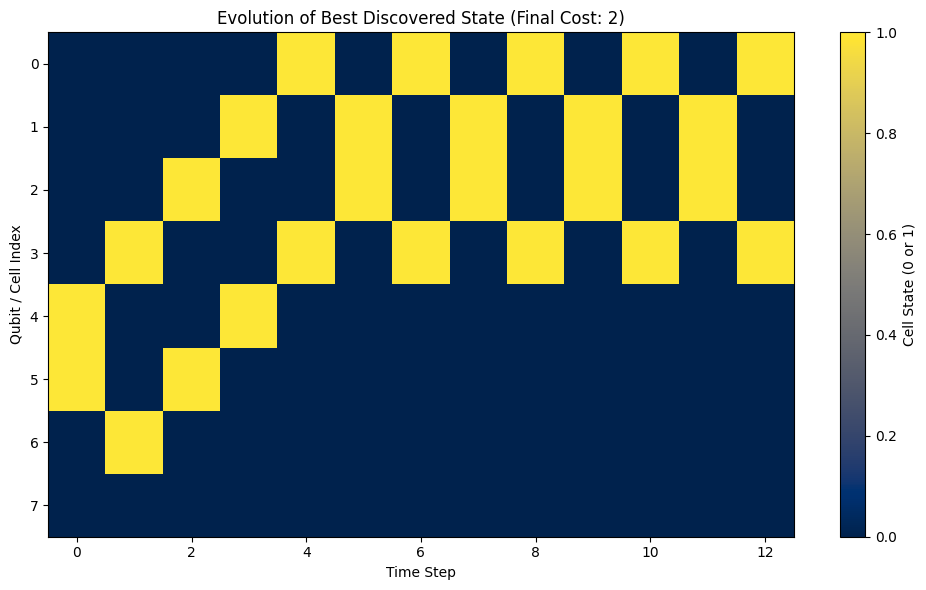

In [ ]:

# ==============================================================================
#  PREAMble: IMPORTS AND SETUP
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Dict

# Qiskit Imports
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import CXGate, CZGate, SwapGate, IGate, XGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

print(f"Qiskit version: {qiskit.__version__}")
print("Running with a MANUALLY IMPLEMENTED optimizer and a DISQUALIFICATION rule.")

# ==============================================================================
#  PART 1: THE QCA UNIVERSE
#  (Unchanged)
# ==============================================================================

GATES = {"CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "I": IGate()}

class QuantumCellularAutomaton:
    """Simulates the deterministic evolution of a QCA for a given initial state."""

    def __init__(self, num_qunodes: int, interaction_config: Dict):
        self.num_qunodes = num_qunodes
        self.interaction_config = interaction_config
        self.simulator = AerSimulator(method='statevector')

    def _get_interaction_unitary(self, type1: int, type2: int):
        key = tuple(sorted((type1, type2)))
        return self.interaction_config.get(key, GATES["I"])

    def evolve_state(self, initial_state: np.ndarray) -> np.ndarray:
        qc_step = QuantumCircuit(self.num_qunodes)

        for i in range(self.num_qunodes):
            if initial_state[i] == 1:
                qc_step.x(i)

        qc_step.barrier(label="init")

        for i in range(self.num_qunodes):
            j_idx = (i + 1) % self.num_qunodes
            op_to_apply = self._get_interaction_unitary(initial_state[i], initial_state[j_idx])

            if op_to_apply.name != 'id':
                qc_step.append(op_to_apply, [i, j_idx])

        final_sv = Statevector(qc_step)
        probs = final_sv.probabilities_dict()
        max_prob_state_str = max(probs, key=probs.get)

        final_state = np.array([int(bit) for bit in max_prob_state_str[::-1]])

        return final_state

    def run_evolution(self, initial_state: np.ndarray, num_steps: int) -> np.ndarray:
        history = [initial_state.copy()]
        current_state = initial_state.copy()
        for _ in range(num_steps):
            current_state = self.evolve_state(current_state)
            history.append(current_state)
        return np.array(history)

# ==============================================================================
#  PART 2: THE QNN GENERATOR
#  (Unchanged)
# ==============================================================================

def create_generator_qnn(num_qubits: int, depth: int) -> QuantumCircuit:
    theta = ParameterVector('θ', num_qubits * depth)
    qc = QuantumCircuit(num_qubits)
    param_idx = 0
    for _ in range(depth):
        for i in range(num_qubits):
            qc.ry(theta[param_idx], i)
            param_idx += 1
        if num_qubits > 1:
            for i in range(num_qubits - 1):
                qc.cz(i, i + 1)
    qc.measure_all()
    return qc

# ==============================================================================
#  PART 3: THE CLASSICAL CRITIC (COST FUNCTION WITH DISQUALIFICATION)
#  (*** THIS PART IS MODIFIED ***)
# ==============================================================================

def create_cost_function_with_disqualification(
    qca: QuantumCellularAutomaton,
    generator_qnn: QuantumCircuit,
    qca_sim_steps: int,
    glider_shift: int
):
    """Creates the cost function that disqualifies trivial states."""
    num_qubits = generator_qnn.num_qubits
    qnn_backend = AerSimulator()

    def cost_function_instance(theta_values):
        # 1. GENERATE a state from the QNN
        bound_circuit = generator_qnn.assign_parameters(theta_values)
        result = qnn_backend.run(bound_circuit, shots=1, memory=True).result()
        initial_state_str = result.get_memory()[0]
        s_initial = np.array([int(bit) for bit in initial_state_str[::-1]])

        # 2. CHECK FOR TRIVIALITY (THE DISQUALIFICATION RULE)
        activity = np.sum(s_initial)
        if activity == 0 or activity == num_qubits:
            # Assign a high cost to disqualify this from being a "perfect" solution
            # The cost must be > 0. The number of qubits is a good non-zero value.
            cost = num_qubits
            return cost, s_initial

        # 3. If not trivial, proceed with normal evaluation
        s_final = s_initial
        for _ in range(qca_sim_steps):
            s_final = qca.evolve_state(s_final)

        # 4. CALCULATE THE GLIDER SCORE
        s_target = np.roll(s_initial, glider_shift)
        cost = np.sum(s_final != s_target)

        return cost, s_initial

    return cost_function_instance

# ==============================================================================
#  PART 4: THE MAIN EXPERIMENT
#  (Modified to use the new cost function)
# ==============================================================================

if __name__ == "__main__":
    # --- Experiment Parameters ---
    NUM_QUBITS = 8
    QNN_DEPTH = 3
    QCA_SIM_STEPS = 4
    GLIDER_SHIFT = -1       # Looking for a glider moving LEFT
    MAX_OPTIM_ITER = 2000   # Give it more time to find a complex solution

    # --- Define the "Laws of Physics" for our QCA Universe ---
    # Using the same rules as before
    QCA_RULES = {
        (0, 0): IGate(),
        (1, 1): CXGate(),
        (0, 1): SwapGate()
    }

    print("--- Starting Glider Discovery Experiment (with Disqualification Rule) ---")
    print(f"Searching for a NON-TRIVIAL {NUM_QUBITS}-qubit glider.")

    qca_universe = QuantumCellularAutomaton(num_qunodes=NUM_QUBITS, interaction_config=QCA_RULES)
    generator_qnn = create_generator_qnn(NUM_QUBITS, QNN_DEPTH)
    print(f"QNN Generator created with {generator_qnn.num_parameters} learnable parameters.")

    cost_function = create_cost_function_with_disqualification(
        qca=qca_universe,
        generator_qnn=generator_qnn,
        qca_sim_steps=QCA_SIM_STEPS,
        glider_shift=GLIDER_SHIFT
    )

    # --- MANUAL OPTIMIZER LOOP ---
    print("\n--- Training the QNN with Manual Optimizer... ---")
    start_time = time.time()

    best_cost = float('inf')
    best_params = None
    best_state = None

    np.random.seed(42)

    for i in range(MAX_OPTIM_ITER):
        current_params = np.random.uniform(0, 2 * np.pi, generator_qnn.num_parameters)
        current_cost, generated_state = cost_function(current_params)

        if current_cost < best_cost:
            best_cost = current_cost
            best_params = current_params
            best_state = generated_state
            print(f"Iter {i+1}: New best cost found! Cost = {best_cost}, State = {best_state}")

        if best_cost == 0:
            print("Perfect non-trivial glider found! Stopping optimization.")
            break

    end_time = time.time()
    print(f"--- Training Complete in {end_time - start_time:.2f} seconds ---")

    # --- Analyze the Results ---
    final_cost = best_cost
    found_glider = best_state

    print(f"\nFinal Best Cost (lower is better): {final_cost}")
    if final_cost == 0:
        print("A cost of 0.0 means a perfect non-trivial glider was found!")

    if found_glider is not None:
        print(f"\nDiscovered Potential Glider State: {found_glider}")

        # --- Verification Step ---
        print("\n--- Verifying the discovered state by plotting its evolution... ---")
        verification_history = qca_universe.run_evolution(
            initial_state=found_glider,
            num_steps=QCA_SIM_STEPS * 3 # Run for longer to see it glide
        )

        plt.figure(figsize=(10, 6))
        plt.imshow(verification_history.T, cmap='cividis', aspect='auto', interpolation='nearest')
        plt.title(f"Evolution of Best Discovered State (Final Cost: {final_cost})")
        plt.xlabel("Time Step")
        plt.ylabel("Qubit / Cell Index")
        plt.colorbar(label="Cell State (0 or 1)")
        plt.yticks(np.arange(NUM_QUBITS))
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo solution was found within the given iterations.")

Qiskit version: 2.0.2
Running with a MANUALLY IMPLEMENTED optimizer and a DISQUALIFICATION rule.
--- Starting Spaceship Confirmation Experiment ---
Searching for a perfect period-8, shift--4 spaceship.
QNN Generator created with 24 learnable parameters.

--- Training the QNN with Manual Optimizer... ---
Iter 1: New best cost found! Cost = 3, State = [1 1 1 0 0 0 1 0]
Iter 9: New best cost found! Cost = 2, State = [0 0 0 0 0 0 1 1]
Iter 30: New best cost found! Cost = 1, State = [1 0 0 0 1 1 1 0]
Iter 120: New best cost found! Cost = 0, State = [0 0 0 0 1 0 0 0]
Perfect spaceship found! Stopping optimization.
--- Training Complete in 1.52 seconds ---

Final Best Cost (lower is better): 0
A cost of 0.0 means the spaceship behavior is confirmed!

Discovered/Confirmed Spaceship State: [0 0 0 0 1 0 0 0]

--- Verifying the discovered state by plotting its evolution... ---


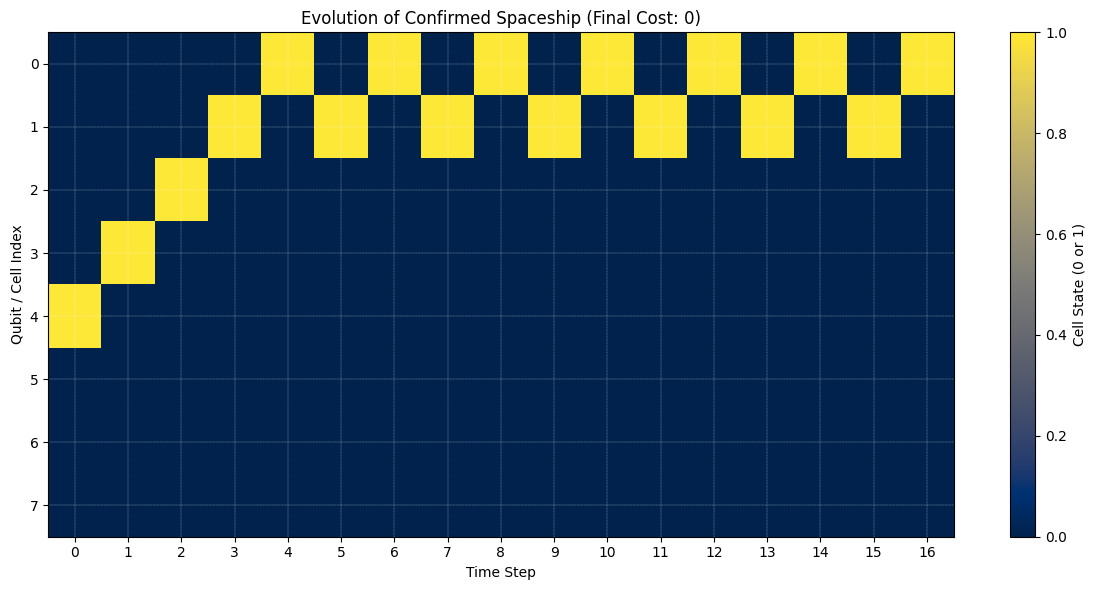

In [ ]:

# ==============================================================================
#  PREAMBLE: IMPORTS AND SETUP
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Dict

# Qiskit Imports
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import CXGate, CZGate, SwapGate, IGate, XGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

print(f"Qiskit version: {qiskit.__version__}")
print("Running with a MANUALLY IMPLEMENTED optimizer and a DISQUALIFICATION rule.")

# ==============================================================================
#  PART 1: THE QCA UNIVERSE
#  (Unchanged)
# ==============================================================================

GATES = {"CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "I": IGate()}

class QuantumCellularAutomaton:
    """Simulates the deterministic evolution of a QCA for a given initial state."""

    def __init__(self, num_qunodes: int, interaction_config: Dict):
        self.num_qunodes = num_qunodes
        self.interaction_config = interaction_config
        self.simulator = AerSimulator(method='statevector')

    def _get_interaction_unitary(self, type1: int, type2: int):
        key = tuple(sorted((type1, type2)))
        return self.interaction_config.get(key, GATES["I"])

    def evolve_state(self, initial_state: np.ndarray) -> np.ndarray:
        qc_step = QuantumCircuit(self.num_qunodes)

        for i in range(self.num_qunodes):
            if initial_state[i] == 1:
                qc_step.x(i)

        qc_step.barrier(label="init")

        for i in range(self.num_qunodes):
            j_idx = (i + 1) % self.num_qunodes
            op_to_apply = self._get_interaction_unitary(initial_state[i], initial_state[j_idx])

            if op_to_apply.name != 'id':
                qc_step.append(op_to_apply, [i, j_idx])

        final_sv = Statevector(qc_step)
        probs = final_sv.probabilities_dict()
        max_prob_state_str = max(probs, key=probs.get)

        final_state = np.array([int(bit) for bit in max_prob_state_str[::-1]])

        return final_state

    def run_evolution(self, initial_state: np.ndarray, num_steps: int) -> np.ndarray:
        history = [initial_state.copy()]
        current_state = initial_state.copy()
        for _ in range(num_steps):
            current_state = self.evolve_state(current_state)
            history.append(current_state)
        return np.array(history)

# ==============================================================================
#  PART 2: THE QNN GENERATOR
#  (Unchanged)
# ==============================================================================

def create_generator_qnn(num_qubits: int, depth: int) -> QuantumCircuit:
    theta = ParameterVector('θ', num_qubits * depth)
    qc = QuantumCircuit(num_qubits)
    param_idx = 0
    for _ in range(depth):
        for i in range(num_qubits):
            qc.ry(theta[param_idx], i)
            param_idx += 1
        if num_qubits > 1:
            for i in range(num_qubits - 1):
                qc.cz(i, i + 1)
    qc.measure_all()
    return qc

# ==============================================================================
#  PART 3: THE CLASSICAL CRITIC (COST FUNCTION WITH DISQUALIFICATION)
#  (Unchanged)
# ==============================================================================

def create_cost_function_with_disqualification(
    qca: QuantumCellularAutomaton,
    generator_qnn: QuantumCircuit,
    qca_sim_steps: int,
    glider_shift: int
):
    """Creates the cost function that disqualifies trivial states."""
    num_qubits = generator_qnn.num_qubits
    qnn_backend = AerSimulator()

    def cost_function_instance(theta_values):
        bound_circuit = generator_qnn.assign_parameters(theta_values)
        result = qnn_backend.run(bound_circuit, shots=1, memory=True).result()
        initial_state_str = result.get_memory()[0]
        s_initial = np.array([int(bit) for bit in initial_state_str[::-1]])

        activity = np.sum(s_initial)
        if activity == 0 or activity == num_qubits:
            cost = num_qubits
            return cost, s_initial

        s_final = s_initial
        for _ in range(qca_sim_steps):
            s_final = qca.evolve_state(s_final)

        s_target = np.roll(s_initial, glider_shift)
        cost = np.sum(s_final != s_target)

        return cost, s_initial

    return cost_function_instance

# ==============================================================================
#  PART 4: THE MAIN EXPERIMENT - CONFIRMATION RUN
#  (*** THIS PART IS MODIFIED ***)
# ==============================================================================

if __name__ == "__main__":
    # --- Experiment Parameters ---
    NUM_QUBITS = 8
    QNN_DEPTH = 3
    # TARGETED SEARCH PARAMETERS
    QCA_SIM_STEPS = 8       # We are hypothesizing a period of 8
    GLIDER_SHIFT = -4       # We are hypothesizing a shift of -4
    MAX_OPTIM_ITER = 3000   # Increase iterations for a more focused search

    # --- Define the "Laws of Physics" for our QCA Universe ---
    # Using the same rules that produced the interesting behavior
    QCA_RULES = {
        (0, 0): IGate(),
        (1, 1): CXGate(),
        (0, 1): SwapGate()
    }

    print("--- Starting Spaceship Confirmation Experiment ---")
    print(f"Searching for a perfect period-{QCA_SIM_STEPS}, shift-{GLIDER_SHIFT} spaceship.")

    qca_universe = QuantumCellularAutomaton(num_qunodes=NUM_QUBITS, interaction_config=QCA_RULES)
    generator_qnn = create_generator_qnn(NUM_QUBITS, QNN_DEPTH)
    print(f"QNN Generator created with {generator_qnn.num_parameters} learnable parameters.")

    cost_function = create_cost_function_with_disqualification(
        qca=qca_universe,
        generator_qnn=generator_qnn,
        qca_sim_steps=QCA_SIM_STEPS,
        glider_shift=GLIDER_SHIFT
    )

    # --- MANUAL OPTIMIZER LOOP ---
    print("\n--- Training the QNN with Manual Optimizer... ---")
    start_time = time.time()

    best_cost = float('inf')
    best_params = None
    best_state = None

    # Use a different seed to see if it finds it from a different starting point
    np.random.seed(101)

    for i in range(MAX_OPTIM_ITER):
        current_params = np.random.uniform(0, 2 * np.pi, generator_qnn.num_parameters)
        current_cost, generated_state = cost_function(current_params)

        if current_cost < best_cost:
            best_cost = current_cost
            best_params = current_params
            best_state = generated_state
            print(f"Iter {i+1}: New best cost found! Cost = {best_cost}, State = {best_state}")

        if best_cost == 0:
            print("Perfect spaceship found! Stopping optimization.")
            break

    end_time = time.time()
    print(f"--- Training Complete in {end_time - start_time:.2f} seconds ---")

    # --- Analyze the Results ---
    final_cost = best_cost
    found_glider = best_state

    print(f"\nFinal Best Cost (lower is better): {final_cost}")
    if final_cost == 0:
        print("A cost of 0.0 means the spaceship behavior is confirmed!")

    if found_glider is not None:
        print(f"\nDiscovered/Confirmed Spaceship State: {found_glider}")

        # --- Verification Step ---
        print("\n--- Verifying the discovered state by plotting its evolution... ---")
        # Run for 2 full periods to see the repetition clearly
        verification_history = qca_universe.run_evolution(
            initial_state=found_glider,
            num_steps=QCA_SIM_STEPS * 2
        )

        plt.figure(figsize=(12, 6))
        plt.imshow(verification_history.T, cmap='cividis', aspect='auto', interpolation='nearest')
        plt.title(f"Evolution of Confirmed Spaceship (Final Cost: {final_cost})")
        plt.xlabel("Time Step")
        plt.ylabel("Qubit / Cell Index")
        plt.colorbar(label="Cell State (0 or 1)")
        plt.yticks(np.arange(NUM_QUBITS))
        plt.xticks(np.arange(len(verification_history)))
        plt.grid(color='white', linestyle='--', linewidth=0.2)
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo solution was found within the given iterations.")

Qiskit version: 2.0.2
LEVEL 1 TEST: Running an identical re-run to test for determinism.
--- Starting Spaceship Confirmation Experiment ---
Searching for a perfect period-8, shift--4 spaceship.
QNN Generator created with 24 learnable parameters.

--- Training the QNN with Manual Optimizer... ---
Iter 1: New best cost found! Cost = 5, State = [0 0 1 1 1 1 1 1]
Iter 2: New best cost found! Cost = 4, State = [1 1 0 0 1 1 0 1]
Iter 3: New best cost found! Cost = 3, State = [1 1 1 0 0 1 1 1]
Iter 11: New best cost found! Cost = 1, State = [0 1 1 0 1 1 1 0]
Iter 36: New best cost found! Cost = 0, State = [0 0 0 0 1 0 0 0]
Perfect spaceship found! Stopping optimization.
--- Training Complete in 1.13 seconds ---

Final Best Cost (lower is better): 0
A cost of 0.0 means the spaceship behavior is confirmed!

Discovered/Confirmed Spaceship State: [0 0 0 0 1 0 0 0]

--- Verifying the discovered state by plotting its evolution... ---


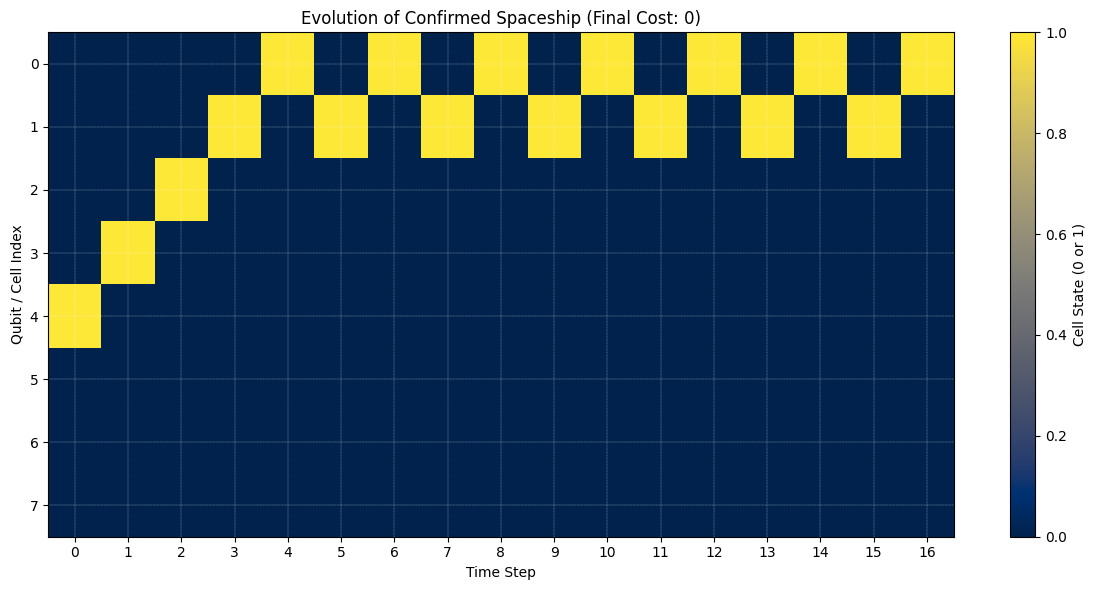

In [ ]:

# ==============================================================================
#  PREAMBLE: IMPORTS AND SETUP
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Dict

# Qiskit Imports
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import CXGate, CZGate, SwapGate, IGate, XGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

print(f"Qiskit version: {qiskit.__version__}")
print("LEVEL 1 TEST: Running an identical re-run to test for determinism.")

# ==============================================================================
#  PART 1: THE QCA UNIVERSE
#  (Unchanged)
# ==============================================================================

GATES = {"CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "I": IGate()}

class QuantumCellularAutomaton:
    """Simulates the deterministic evolution of a QCA for a given initial state."""

    def __init__(self, num_qunodes: int, interaction_config: Dict):
        self.num_qunodes = num_qunodes
        self.interaction_config = interaction_config
        self.simulator = AerSimulator(method='statevector')

    def _get_interaction_unitary(self, type1: int, type2: int):
        key = tuple(sorted((type1, type2)))
        return self.interaction_config.get(key, GATES["I"])

    def evolve_state(self, initial_state: np.ndarray) -> np.ndarray:
        qc_step = QuantumCircuit(self.num_qunodes)

        for i in range(self.num_qunodes):
            if initial_state[i] == 1:
                qc_step.x(i)

        qc_step.barrier(label="init")

        for i in range(self.num_qunodes):
            j_idx = (i + 1) % self.num_qunodes
            op_to_apply = self._get_interaction_unitary(initial_state[i], initial_state[j_idx])

            if op_to_apply.name != 'id':
                qc_step.append(op_to_apply, [i, j_idx])

        final_sv = Statevector(qc_step)
        probs = final_sv.probabilities_dict()
        max_prob_state_str = max(probs, key=probs.get)

        final_state = np.array([int(bit) for bit in max_prob_state_str[::-1]])

        return final_state

    def run_evolution(self, initial_state: np.ndarray, num_steps: int) -> np.ndarray:
        history = [initial_state.copy()]
        current_state = initial_state.copy()
        for _ in range(num_steps):
            current_state = self.evolve_state(current_state)
            history.append(current_state)
        return np.array(history)

# ==============================================================================
#  PART 2: THE QNN GENERATOR
#  (Unchanged)
# ==============================================================================

def create_generator_qnn(num_qubits: int, depth: int) -> QuantumCircuit:
    theta = ParameterVector('θ', num_qubits * depth)
    qc = QuantumCircuit(num_qubits)
    param_idx = 0
    for _ in range(depth):
        for i in range(num_qubits):
            qc.ry(theta[param_idx], i)
            param_idx += 1
        if num_qubits > 1:
            for i in range(num_qubits - 1):
                qc.cz(i, i + 1)
    qc.measure_all()
    return qc

# ==============================================================================
#  PART 3: THE CLASSICAL CRITIC (COST FUNCTION WITH DISQUALIFICATION)
#  (Unchanged)
# ==============================================================================

def create_cost_function_with_disqualification(
    qca: QuantumCellularAutomaton,
    generator_qnn: QuantumCircuit,
    qca_sim_steps: int,
    glider_shift: int
):
    """Creates the cost function that disqualifies trivial states."""
    num_qubits = generator_qnn.num_qubits
    qnn_backend = AerSimulator()

    def cost_function_instance(theta_values):
        bound_circuit = generator_qnn.assign_parameters(theta_values)
        result = qnn_backend.run(bound_circuit, shots=1, memory=True).result()
        initial_state_str = result.get_memory()[0]
        s_initial = np.array([int(bit) for bit in initial_state_str[::-1]])

        activity = np.sum(s_initial)
        if activity == 0 or activity == num_qubits:
            cost = num_qubits
            return cost, s_initial

        s_final = s_initial
        for _ in range(qca_sim_steps):
            s_final = qca.evolve_state(s_final)

        s_target = np.roll(s_initial, glider_shift)
        cost = np.sum(s_final != s_target)

        return cost, s_initial

    return cost_function_instance

# ==============================================================================
#  PART 4: THE MAIN EXPERIMENT - THE RE-RUN
#  (Unchanged)
# ==============================================================================

if __name__ == "__main__":
    # --- Experiment Parameters ---
    NUM_QUBITS = 8
    QNN_DEPTH = 3
    QCA_SIM_STEPS = 8
    GLIDER_SHIFT = -4
    MAX_OPTIM_ITER = 3000

    # --- Define the "Laws of Physics" for our QCA Universe ---
    QCA_RULES = {
        (0, 0): IGate(),
        (1, 1): CXGate(),
        (0, 1): SwapGate()
    }

    print("--- Starting Spaceship Confirmation Experiment ---")
    print(f"Searching for a perfect period-{QCA_SIM_STEPS}, shift-{GLIDER_SHIFT} spaceship.")

    qca_universe = QuantumCellularAutomaton(num_qunodes=NUM_QUBITS, interaction_config=QCA_RULES)
    generator_qnn = create_generator_qnn(NUM_QUBITS, QNN_DEPTH)
    print(f"QNN Generator created with {generator_qnn.num_parameters} learnable parameters.")

    cost_function = create_cost_function_with_disqualification(
        qca=qca_universe,
        generator_qnn=generator_qnn,
        qca_sim_steps=QCA_SIM_STEPS,
        glider_shift=GLIDER_SHIFT
    )

    # --- MANUAL OPTIMIZER LOOP ---
    print("\n--- Training the QNN with Manual Optimizer... ---")
    start_time = time.time()

    best_cost = float('inf')
    best_params = None
    best_state = None

    # This seed ensures the "random" search is identical every time.
    np.random.seed(101)

    for i in range(MAX_OPTIM_ITER):
        current_params = np.random.uniform(0, 2 * np.pi, generator_qnn.num_parameters)
        current_cost, generated_state = cost_function(current_params)

        if current_cost < best_cost:
            best_cost = current_cost
            best_params = current_params
            best_state = generated_state
            print(f"Iter {i+1}: New best cost found! Cost = {best_cost}, State = {best_state}")

        if best_cost == 0:
            print("Perfect spaceship found! Stopping optimization.")
            break

    end_time = time.time()
    print(f"--- Training Complete in {end_time - start_time:.2f} seconds ---")

    # --- Analyze the Results ---
    final_cost = best_cost
    found_glider = best_state

    print(f"\nFinal Best Cost (lower is better): {final_cost}")
    if final_cost == 0:
        print("A cost of 0.0 means the spaceship behavior is confirmed!")

    if found_glider is not None:
        print(f"\nDiscovered/Confirmed Spaceship State: {found_glider}")

        # --- Verification Step ---
        print("\n--- Verifying the discovered state by plotting its evolution... ---")
        verification_history = qca_universe.run_evolution(
            initial_state=found_glider,
            num_steps=QCA_SIM_STEPS * 2
        )

        plt.figure(figsize=(12, 6))
        plt.imshow(verification_history.T, cmap='cividis', aspect='auto', interpolation='nearest')
        plt.title(f"Evolution of Confirmed Spaceship (Final Cost: {final_cost})")
        plt.xlabel("Time Step")
        plt.ylabel("Qubit / Cell Index")
        plt.colorbar(label="Cell State (0 or 1)")
        plt.yticks(np.arange(NUM_QUBITS))
        plt.xticks(np.arange(len(verification_history)))
        plt.grid(color='white', linestyle='--', linewidth=0.2)
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo solution was found within the given iterations.")